In [45]:
import pandas as pd
import re
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

df = pd.read_json("../data/vanilla_processed.json")

# choose your text column
texts = df["caption_text"].fillna("").astype(str).tolist()

In [46]:
len(df)

124

In [47]:
import os
print(os.getcwd())

c:\univ\Data mining\Project\notebooks


In [48]:
import ast
import re
import pandas as pd

def _parse_hashtag_tokens(val):
    if val is None or (isinstance(val, float) and pd.isna(val)):
        return []

    if isinstance(val, list):
        raw = val
    else:
        s = str(val).strip()
        if not s:
            return []

        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, list):
                raw = parsed
            else:
                raw = re.findall(r"(?<!\w)#([^\s#]+)", s, flags=re.UNICODE)
        except Exception:
            if "|" in s:
                raw = s.split("|")
            elif "," in s:
                raw = s.split(",")
            else:
                raw = re.findall(r"(?<!\w)#([^\s#]+)", s, flags=re.UNICODE)

    out = []
    for x in raw:
        t = str(x).strip().lower().lstrip("#")

        # Arabic normalization for hashtag tokens too
        t = re.sub(r"[إأآا]", "ا", t)
        t = re.sub(r"ى", "ي", t)
        t = re.sub(r"ؤ", "و", t)
        t = re.sub(r"ئ", "ي", t)
        t = re.sub(r"ة", "ه", t)
        t = re.sub(r"ـ", "", t)
        t = re.sub(r"[\u064B-\u065F\u0670]", "", t)

        # keep Arabic, English letters/numbers, underscore
        t = re.sub(r"[^\w\u0600-\u06FF]+", "", t)

        if t:
            out.append(t)

    return list(dict.fromkeys(out))


def clean_caption(text, hashtags_value=None):
    text = str(text).lower()

    # remove URLs and mentions
    text = re.sub(r"http\S+|www\S+|@\w+", " ", text)

    # remove hashtags with leading #
    text = re.sub(r"#\S+", " ", text)

    # remove phone numbers
    text = re.sub(r"\b\d{5,}\b", " ", text)

    # normalize Arabic letters
    text = re.sub(r"[إأآا]", "ا", text)
    text = re.sub(r"ى", "ي", text)
    text = re.sub(r"ؤ", "و", text)
    text = re.sub(r"ئ", "ي", text)
    text = re.sub(r"ة", "ه", text)

    # remove tatweel and diacritics
    text = re.sub(r"ـ", "", text)
    text = re.sub(r"[\u064B-\u065F\u0670]", "", text)

    # remove symbols, keep Arabic/English/numbers/spaces
    text = re.sub(r"[^\w\s\u0600-\u06FF]", " ", text)

    # remove explicit hashtag words from hashtags column
    tag_terms = _parse_hashtag_tokens(hashtags_value)

    for term in tag_terms:
        # remove full hashtag token
        text = re.sub(rf"(?<!\w){re.escape(term)}(?!\w)", " ", text)

        # remove parts of snake_case hashtags
        for part in term.split("_"):
            if len(part) >= 3:
                text = re.sub(rf"(?<!\w){re.escape(part)}(?!\w)", " ", text)

    # normalize spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


if "hashtags" in df.columns:
    df["clean_caption"] = [
        clean_caption(t, h)
        for t, h in zip(df["caption_text"].fillna(""), df["hashtags"])
    ]
else:
    df["clean_caption"] = df["caption_text"].fillna("").apply(
        lambda x: clean_caption(x, None)
    )

texts = df["clean_caption"].tolist()

In [63]:
len(texts)

124

In [50]:
from pathlib import Path
from sentence_transformers import SentenceTransformer
import os

# 1) Local cache directory inside project
LOCAL_MODEL_DIR = Path("./.local_models/sentence_transformers/all-MiniLM-L6-v2")
LOCAL_MODEL_DIR.parent.mkdir(parents=True, exist_ok=True)

# 2) Load from local if exists, otherwise download once then save locally
if LOCAL_MODEL_DIR.exists() and any(LOCAL_MODEL_DIR.iterdir()):
    model = SentenceTransformer(str(LOCAL_MODEL_DIR), local_files_only=True)
else:
    model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
    model.save(str(LOCAL_MODEL_DIR))  # saves full model locally for reuse

print(f"Using model from: {LOCAL_MODEL_DIR.resolve()}")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5424.51it/s]

Using model from: C:\univ\Data mining\Project\notebooks\.local_models\sentence_transformers\all-MiniLM-L6-v2


In [132]:
from sklearn.feature_extraction.text import  ENGLISH_STOP_WORDS


arabic_stop_words = [
    "في", "من", "على", "الى", "إلى", "عن", "مع", "هذا", "هذه", "ذلك",
    "هو", "هي", "هم", "ما", "لا", "نعم", "او", "أو", "كل", "تم",
    "الله", "ان", "إن", "أن", "كان", "كانت", "بعد", "قبل",

    # "متوفر", "متوفره", "متوفرة", "عرض", "عروض", "خصم", "السعر",
    # "اسعار", "للطلب", "للتواصل", "تواصل", "رسائل", "الصفحه",
    # "الصفحة", "واتساب", "رقم", "اتصال", "التوصيل", "دليفري",
    # "اليوم", "جديد", "جديدنا", "تابعونا", "زورونا",
]

extra_noise_words = [
    # "available", "new", "just", "time", "pro",
    "2024", "2025", "2026",
    "gaza",  # remove only if location is not your goal
]

combined_stop_words = list(
    set(arabic_stop_words)
    .union(ENGLISH_STOP_WORDS)
    .union(extra_noise_words)
)

vectorizer_model = CountVectorizer(
    stop_words=combined_stop_words,
    ngram_range=(1, 1),
    min_df=2,
    token_pattern=r"(?u)\b[^\W\d_][^\W_]+\b"  
)

In [133]:
from hdbscan import HDBSCAN
from umap import UMAP

# Use more permissive clustering to avoid collapsing into too few clusters
umap_model = UMAP(n_neighbors=10, n_components=5, min_dist=0.0, metric="cosine", random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=8, min_samples=2, metric="euclidean", cluster_selection_method="eom", prediction_data=True)

topic_model = BERTopic(
    embedding_model=model,
    vectorizer_model=vectorizer_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    language="multilingual",
    min_topic_size=8,
    calculate_probabilities=True,
    verbose=True,
    top_n_words=20
)

topics, probs = topic_model.fit_transform(texts)
print("Unique topics:", sorted(set(topics)))
print(topic_model.get_topic_info()[["Topic", "Count", "Name"]])


2026-05-15 00:51:16,409 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 4/4 [00:01<00:00,  3.22it/s]
2026-05-15 00:51:17,660 - BERTopic - Embedding - Completed ✓
2026-05-15 00:51:17,661 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-15 00:51:17,886 - BERTopic - Dimensionality - Completed ✓
2026-05-15 00:51:17,887 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-15 00:51:17,895 - BERTopic - Cluster - Completed ✓
2026-05-15 00:51:17,897 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-15 00:51:17,905 - BERTopic - Representation - Completed ✓


Unique topics: [-1, 0, 1, 2, 3, 4, 5]
   Topic  Count                       Name
0     -1      2         -1_علي_ام_مين_انها
1      0     30      0_رمضان_فانيلا_شو_فرع
2      1     30  1_cake_new_vanilla_coffee
3      2     20      2_الان_فانيلا_كيك_فرع
4      3     19   3_vanilla_فقط_coffee_وكل
5      4     15     4_وكل_اليوم_يوم_فانيلا
6      5      8      5_اكبر_like_كريم_كيكه


In [134]:
# topic_model.reduce_topics(texts, nr_topics="auto")

In [135]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2,-1_علي_ام_مين_انها,"[علي, ام, مين, انها, فانيلا, , , , , , , , , , , , , , , ]","[مين جاهز للحلويات الرمضانيه؟, كلكم اتفقتوا علي انها اطيب ام علي في فانيلا]"
1,0,30,0_رمضان_فانيلا_شو_فرع,"[رمضان, فانيلا, شو, فرع, نابلس, ام, ramadan, ايام, شاركونا, البوفيه, بالتعليقات, فيكم, مشاريب, كريم, فرنش, عجيب, الافطار, توست, بوفيه, الرمضاني]","[هذا ما نقدمه لكم حلي رمضان النهايي, 16 رمضان, رمضان فانيلا]"
2,1,30,1_cake_new_vanilla_coffee,"[cake, new, vanilla, coffee, freshly, cheesecake, favorite, berries, cream, hot, taste, , , , , , , , , ]","[dream vanilla cake creamy and yummy, new mix berries cake the cake you always dreamed about is now available at all vanilla branches, the new very chocolate cake]"
3,2,20,2_الان_فانيلا_كيك_فرع,"[الان, فانيلا, كيك, فرع, كيكه, للحجز, وفرع, الطيره, الرمضاني, بوفيه, يوم, تشيزكيك, عجيب, سان, نابلس, الافطار, توست, شو, علي, اليوم]","[بوفيه الافطار الرمضاني في فانيلا فرع الطيره وفرع نابلس للحجز او عبر رسايل الصفحه نستقبل المكالمات يوميا بعد الساعه الواحده ظهرا, بوفيه الافطار الرمضاني في فانيلا فرع الطيره وفرع نابلس للحجز او عبر رسايل الصفحه نستقبل المكالمات يوميا بعد الساعه الواحده ظهرا, نستقبل حجوزاتكم الان بوفيه فانيلا الر..."
4,3,19,3_vanilla_فقط_coffee_وكل,"[vanilla, فقط, coffee, وكل, اليوم, علي, cream, الكراميل, taste, like, شاركونا, favorite, ramadan, hot, berries, فيكم, مين, بمناسبه, انت, يوم]","[سعيد صباحكم من فانيلا vanilla, طول بالك لما تتعب بالزينه بالاخر يغير رايه الزبون ويصير بده اياها برا vanilla, شرب القهوه بالليل يوذي المعده؟ vanilla]"
5,4,15,4_وكل_اليوم_يوم_فانيلا,"[وكل, اليوم, يوم, فانيلا, الطيره, نابلس, انت, بمناسبه, فرعنا, لقمه, الصحيح, البوفيه, مشاريب, انها, وفرع, الافطار, للحجز, الرمضاني, بوفيه, فرع]","[نقطه ضعف بطعم الفيريرو فانيلا اليوم وكل يوم, بتشاركوهم ولا بتخلصهم لحالك؟ share it or all yours ؟ فانيلا اليوم وكل يوم, فانيلا الها حكايه والحكايه بلشت من هون فانيلا اليوم وكل يوم]"
6,5,8,5_اكبر_like_كريم_كيكه,"[اكبر, like, كريم, كيكه, كيك, نابلس, يوم, فانيلا, , , , , , , , , , , , ]","[كارميل كرانش كريم كيكه جديده من فانيلا, اكبر كميه كوكيز, اكبر كميه لفرع نابلس]"


In [136]:
topic_model.get_topic(0)

[('رمضان', np.float64(0.24618008080818843)),
 ('فانيلا', np.float64(0.18010464112843058)),
 ('شو', np.float64(0.11636388527922087)),
 ('فرع', np.float64(0.0919139742431474)),
 ('نابلس', np.float64(0.08157084095764378)),
 ('ام', np.float64(0.07426036163924253)),
 ('ramadan', np.float64(0.07426036163924253)),
 ('ايام', np.float64(0.07426036163924253)),
 ('شاركونا', np.float64(0.07426036163924253)),
 ('البوفيه', np.float64(0.07426036163924253)),
 ('بالتعليقات', np.float64(0.07426036163924253)),
 ('فيكم', np.float64(0.07426036163924253)),
 ('مشاريب', np.float64(0.07426036163924253)),
 ('كريم', np.float64(0.07426036163924253)),
 ('فرنش', np.float64(0.06475667913614568)),
 ('عجيب', np.float64(0.06475667913614568)),
 ('الافطار', np.float64(0.058181942639610434)),
 ('توست', np.float64(0.058181942639610434)),
 ('بوفيه', np.float64(0.0532057926462317)),
 ('الرمضاني', np.float64(0.0532057926462317))]

In [137]:
print(topic_model.topic_embeddings_ is None)
print(0 if topic_model.topic_embeddings_ is None else len(topic_model.topic_embeddings_))
print(topic_model.get_topic_info())


False
7
   Topic  Count                       Name  \
0     -1      2         -1_علي_ام_مين_انها   
1      0     30      0_رمضان_فانيلا_شو_فرع   
2      1     30  1_cake_new_vanilla_coffee   
3      2     20      2_الان_فانيلا_كيك_فرع   
4      3     19   3_vanilla_فقط_coffee_وكل   
5      4     15     4_وكل_اليوم_يوم_فانيلا   
6      5      8      5_اكبر_like_كريم_كيكه   

                                                                                                                                     Representation  \
0                                                                                        [علي, ام, مين, انها, فانيلا, , , , , , , , , , , , , , , ]   
1  [رمضان, فانيلا, شو, فرع, نابلس, ام, ramadan, ايام, شاركونا, البوفيه, بالتعليقات, فيكم, مشاريب, كريم, فرنش, عجيب, الافطار, توست, بوفيه, الرمضاني]   
2                                         [cake, new, vanilla, coffee, freshly, cheesecake, favorite, berries, cream, hot, taste, , , , , , , , , ]   
3               [ال

In [138]:
info = topic_model.get_topic_info()
non_outlier_topics = info[info["Topic"] != -1]["Topic"].tolist()

print("Number of non-outlier topics:", len(non_outlier_topics))
print(non_outlier_topics)

if len(non_outlier_topics) >= 3:
    topic_model.visualize_topics(topics=non_outlier_topics)
else:
    print("Too few topics for intertopic map. Showing barchart instead.")
    topic_model.visualize_barchart(
        topics=non_outlier_topics,
        top_n_topics=len(non_outlier_topics)
    )

Number of non-outlier topics: 6
[0, 1, 2, 3, 4, 5]


In [139]:
topic_model.visualize_topics()

In [140]:
topic_model.visualize_barchart(top_n_topics=2)
topic_model.visualize_hierarchy()
topic_model.visualize_heatmap()


In [130]:
!pip install matplotlib arabic-reshaper python-bidi



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


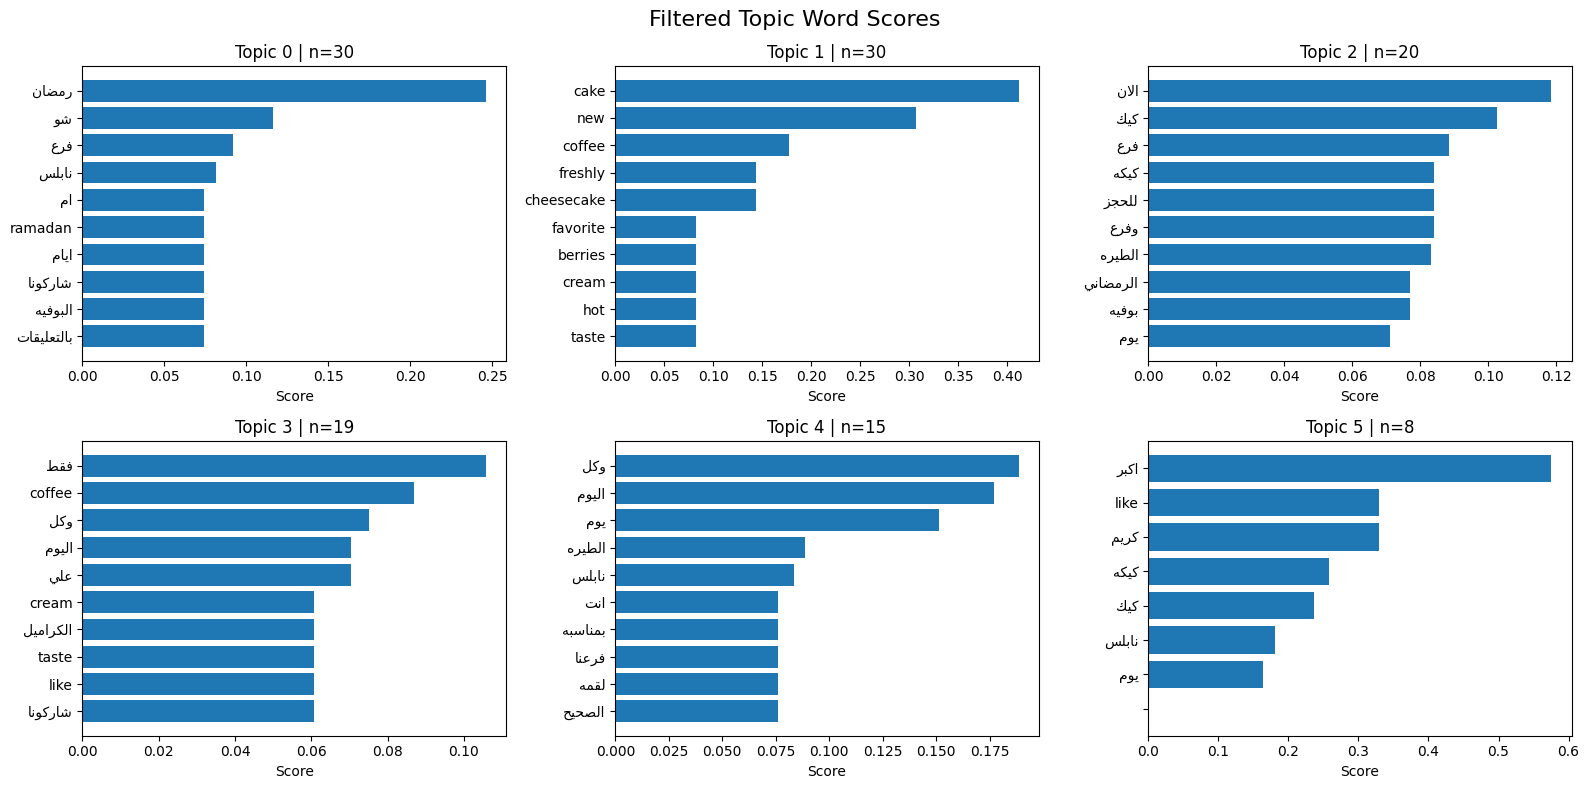

In [141]:
import math
import matplotlib.pyplot as plt
import arabic_reshaper
from bidi.algorithm import get_display
topic_info = topic_model.get_topic_info()

topic_sizes = dict(zip(topic_info["Topic"], topic_info["Count"]))

topics_to_plot = (
    topic_info[topic_info["Topic"] != -1]["Topic"]
    .head(10)
    .tolist()
)

top_n_words = 10
cols = 3
rows = math.ceil(len(topics_to_plot) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()

for ax, topic_id in zip(axes, topics_to_plot):
    words_scores = get_filtered_topic_words(
        topic_model,
        topic_id,
        top_n=top_n_words
    )

    topic_size = topic_sizes.get(topic_id, 0)

    if not words_scores:
        ax.set_title(f"Topic {topic_id} | n={topic_size} - no words")
        ax.axis("off")
        continue

    words = [fix_arabic(w) for w, s in words_scores]
    scores = [s for w, s in words_scores]

    words = words[::-1]
    scores = scores[::-1]

    ax.barh(words, scores)
    ax.set_title(f"Topic {topic_id} | n={topic_size}")
    ax.set_xlabel("Score")

for ax in axes[len(topics_to_plot):]:
    ax.axis("off")

plt.suptitle("Filtered Topic Word Scores", fontsize=16)
plt.tight_layout()
plt.show()

In [87]:
df = df.copy()
df["topic_id"] = topics

rows = []

for topic_id, group in df[df["topic_id"] != -1].groupby("topic_id"):
    sample = group.sample(min(2, len(group)), random_state=42)
    rows.append(sample)

topic_samples = pd.concat(rows, ignore_index=True)

sample_cols = [
    "topic_id",
    "caption_text",
    "clean_caption",
    "view_rate",
    "engagement_rate",
    "likes_count",
    "comments_count"
]

sample_cols = [c for c in sample_cols if c in topic_samples.columns]

topic_samples = topic_samples.sort_values("topic_id")[sample_cols]

pd.set_option("display.max_colwidth", 300)
topic_samples


,topic_id,caption_text,clean_caption,likes_count,comments_count
0,0,مكانكم المفضل ❤️ #فانيلا_اليوم_وكل_يوم,مكانكم المفضل,1300,2
1,0,بعد الإفطار في فانيلا 🌙🤍✌️,بعد الافطار في فانيلا,2898,4
2,1,Summer’s calling 📞 Grab your Yafa Refresher at VANILLA! 🍹☀️ #VANILLA_Today_and_everyday,summer s calling grab your yafa refresher at vanilla,1300,0
3,1,New year new me 😍😍😍,new year new me,2155,10
4,2,ومن أهم فوائدها إنها تذهب الحزن.. التلبينة النبوية.. صحية، فوائدها كثيرة ولذيذة هي طبق تقليدي قديم ذكرها الرسول محمد صلى الله عليه وسلم في أحاديث لها فيها من فوائد وشفاء #فانيلا_اليوم_وكل_يوم #vanilla_today_and_everyday,ومن اهم فوايدها انها تذهب الحزن التلبينه النبويه صحيه، فوايدها كثيره ولذيذه هي طبق تقليدي قديم ذكرها الرسول محمد صلي الله عليه وسلم في احاديث لها فيها من فوايد وشفاء,1313,0
5,2,أمي.. كل عام وأنتِ أجمل نعمة 💜 هذا يومك، نقدّر وجودك بكل لحظة من فانيلا 🎂 الحجوزات عبر رسائل الصفحة 💌,امي كل عام وانت اجمل نعمه هذا يومك، نقدر وجودك بكل لحظه من فانيلا الحجوزات عبر رسايل الصفحه,44,4
6,3,استمر بالأكل أنت بأمان 😜🤤 #فانيلا_اليوم_وكل_يوم #طعام #وزن #أكل #كيك VANILLA #Today_and_Everyday #Food #Eating #Cake #Desserts,استمر بالاكل انت بامان vanilla,963,5
7,3,قاعدين على قلوبكم ❤️🥳 #فانيلا_اليوم_وكل_يوم #كيك #قهوة #وينجز #مشاريب VANILLA #Today_and_Everyday #wings #coffee #cake #drinks,قاعدين علي قلوبكم vanilla,1080,7
8,4,طبقات من القشطة و التمر الفاخر 🌙😍,طبقات من القشطه و التمر الفاخر,1475,2
9,4,Perfect Alfajores🤭,perfect alfajores,541,11


In [88]:
import pandas as pd
import numpy as np

# Make sure topic_id exists
df = df.copy()
df["topic_id"] = topics

# Remove outlier topic -1
df_topics = df[df["topic_id"] != -1].copy()

# Numeric columns you may have
possible_numeric_cols = [
    "view_rate",
    "engagement_rate",
    "likes_count",
    "comments_count",
    "views_count",
    "caption_length",
    "hashtags_count",
    "emoji_count"
]

numeric_cols = [c for c in possible_numeric_cols if c in df_topics.columns]

# Base topic summary
topic_summary = (
    df_topics
    .groupby("topic_id")
    .agg(
        posts=("topic_id", "size"),
        **{
            f"median_{col}": (col, "median")
            for col in numeric_cols
        },
        **{
            f"mean_{col}": (col, "mean")
            for col in numeric_cols
        }
    )
    .reset_index()
)

topic_summary

,topic_id,posts,median_likes_count,median_comments_count,median_views_count,median_caption_length,median_hashtags_count,median_emoji_count,mean_likes_count,mean_comments_count,mean_views_count,mean_caption_length,mean_hashtags_count,mean_emoji_count
0,0,30,914.5,7.5,107800.0,27.5,0.5,1.0,1026.933333,22.266667,181673.333333,33.300000,0.900000,1.400000
1,1,30,1019.0,14.0,149500.0,68.0,1.0,1.5,1598.866667,269.333333,251506.666667,72.733333,1.866667,1.866667
2,2,20,520.5,45.0,122000.0,180.0,3.5,4.0,634.200000,253.700000,192950.000000,198.500000,2.900000,4.350000
3,3,19,788.0,13.0,136000.0,142.0,4.0,2.0,781.736842,203.947368,149442.105263,153.315789,5.105263,2.105263
4,4,15,557.0,11.0,238000.0,84.0,2.0,1.0,834.733333,328.400000,337266.666667,93.866667,3.066667,2.000000
5,5,8,365.5,2.0,271000.0,64.5,2.0,2.0,979.250000,7.125000,337312.500000,62.375000,2.250000,1.500000


In [75]:

topic_info = topic_model.get_topic_info()
df = df.merge(
    topic_info[["Topic", "Name"]],
    left_on="topic_id",
    right_on="Topic",
    how="left"
)

df.to_csv("dataset_with_topics.csv", index=False)

In [ ]:
topic_info = topic_model.get_topic_info()

for topic_id in topic_info["Topic"]:
    if topic_id == -1:
        continue

    keywords = topic_model.get_topic(topic_id)
    docs = topic_model.get_representative_docs(topic_id)

    print("\nTopic:", topic_id)
    print("Keywords:", keywords[:10])
    print("Examples:", docs[:3])

In [ ]:
# Safe topic visualization: avoid UMAP crash when non-outlier topics are too few
info = topic_model.get_topic_info()
non_outlier_topics = info[info["Topic"] != -1]["Topic"].tolist()
print("Non-outlier topics:", non_outlier_topics)

if len(non_outlier_topics) >= 3:
    fig = topic_model.visualize_topics(topics=non_outlier_topics)
    fig
else:
    print("Not enough non-outlier topics for intertopic UMAP map; showing bar chart instead.")
    fig = topic_model.visualize_barchart(topics=non_outlier_topics if non_outlier_topics else None, top_n_topics=len(non_outlier_topics) or 1)
    fig
